# Week 5 - DBSCAN + Hierarchical Clustering

**Goal:** Compare two clustering approaches: *DBSCAN* and *Hierarchical Clustering*, and determine which gives the best clustering structure for your dataset in terms of separation, interpretability, and practicality.

## A. Setup + Data Preparation

### 0. Setup

In [45]:
import os
import sys
import platform
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd

from matplotlib import pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram

print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
print('pandas:', pd.__version__)

Python: 3.13.7
Platform: Linux-6.17.0-19-generic-x86_64-with-glibc2.42
pandas: 3.0.1


In [2]:
from pathlib import Path

PROJECT_ROOT = Path.cwd() / "no_show_predict"
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS = PROJECT_ROOT / "reports"
CONFIGS = PROJECT_ROOT / "configs"

PROJECT_ROOT

PosixPath('/media/irseora/external/Repos/Data-Science/no_show_predict')

### 1. Load Dataset

In [4]:
data_path = DATA_PROCESSED / "appointments_processed.csv"
data = pd.read_csv(data_path)
print(data.shape)
data.head()

(110527, 15)


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hypertension,Diabetes,Alcoholism,Handicap,SMSReceived,NoShow,WaitingDays
0,2.987250e+13,5642903,F,2016-04-29 18:38:08+00:00,2016-04-29 00:00:00+00:00,62,JARDIM DA PENHA,False,True,False,False,False,False,False,0
1,5.589978e+14,5642503,M,2016-04-29 16:08:27+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,False,False,False,False,False,False,False,0
2,4.262962e+12,5642549,F,2016-04-29 16:19:04+00:00,2016-04-29 00:00:00+00:00,62,MATA DA PRAIA,False,False,False,False,False,False,False,0
3,8.679512e+11,5642828,F,2016-04-29 17:29:31+00:00,2016-04-29 00:00:00+00:00,8,PONTAL DE CAMBURI,False,False,False,False,False,False,False,0
4,8.841186e+12,5642494,F,2016-04-29 16:07:23+00:00,2016-04-29 00:00:00+00:00,56,JARDIM DA PENHA,False,True,True,False,False,False,False,0


### 2. Define Feature Matrix

Numeric features only

In [9]:
# Features
x = (
    data
    .drop(columns = ["NoShow"])
    .select_dtypes(include = ["number", "bool"])
    .astype(float)
)

print("Number of features:", x.shape[1])
print("Feature names:")
for col in x.columns:
    print("-", col)

Number of features: 10
Feature names:
- PatientId
- AppointmentID
- Age
- Scholarship
- Hypertension
- Diabetes
- Alcoholism
- Handicap
- SMSReceived
- WaitingDays


### 3. Standardize Features

In [11]:
prep = Pipeline([
    ("scaler", StandardScaler())
])

x_scaled = prep.fit_transform(x)

### 4. Clustering Evaluation Metric

**Chosen metric:** Silhouette score

## B. DBSCAN

### B1. Initial DBSCAN Model

In [34]:
def run_dbscan(eps = 0.8, min_samples = 5):
    dbscan = DBSCAN(eps = eps, min_samples = min_samples)
    labels_db = dbscan.fit_predict(x_scaled)

    return labels_db

In [35]:
def get_results(labels_db):
    # Number of clusters (excluding noise label -1)
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)

    # Number of noise points
    n_noise = np.sum(labels_db == -1)

    # Silhouette score (on a subset to run faster)
    # score = silhouette_score(x_scaled, labels_db)
    mask = labels_db != -1
    x_non_noise = x_scaled[mask]
    labels_non_noise = labels_db[mask]
    score = silhouette_score(
        x_non_noise, labels_non_noise,
        sample_size = 2000,
        random_state = 42
    )

    results = (eps, min_samples, n_clusters, n_noise, score)
    return(results)

In [36]:
eps = 0.8
min_samples = 5
labels_db = run_dbscan()

results_initial = get_results(labels_db)
eps, min_samples, n_clusters, n_noise, score = results_initial

print("Initial DBSCAN Model")
report_initial = pd.DataFrame([{
    "eps": eps,
    "min_samples": min_samples,
    "n_clusters": n_clusters,
    "n_noise": n_noise,
    "silhouette_score": score
}])
display(report_initial)

Initial DBSCAN Model


,eps,min_samples,n_clusters,n_noise,silhouette_score
0,0.8,5,74,953,0.313963


### B2. Parameter Exploration

#### 1. Parameter Configuration 1 - Strict Neighborhood

In [37]:
eps = 0.3
min_samples = 5
labels_db = run_dbscan(eps, min_samples)

results_config_1 = get_results(labels_db)
print("Results saved. Final report below.")

Results saved. Final report below.


#### 2. Parameter Configuration 2 - Middleground

In [38]:
eps = 0.5
min_samples = 5
labels_db = run_dbscan(eps, min_samples)

results_config_2 = get_results(labels_db)
print("Results saved. Final report below.")

Results saved. Final report below.


#### 3. Parameter Configuration 3 - Loose Neighborhood

In [39]:
eps = 1.0
min_samples = 5
labels_db = run_dbscan(eps, min_samples)

results_config_3 = get_results(labels_db)
print("Results saved. Final report below.")

Results saved. Final report below.


#### 4. Report

In [54]:
report_dbscan = pd.DataFrame(
    [ results_config_1, results_config_2, results_config_3 ],
    columns = [ "eps", "min_samples", "n_clusters", "n_noise", "silhouette_score" ]
)
display(report_dbscan)

,eps,min_samples,n_clusters,n_noise,silhouette_score
0,0.3,5,309,10710,0.150784
1,0.5,5,138,3220,0.290597
2,1.0,5,64,553,0.316846


**Interpretation:**<br/>
Increasing `eps` reduced the number of clusters and the number of noise points, because more points were considered part of the same dense region.<br/>
In this dataset, larger `eps` values improved the silhouette score, suggesting that the smaller values were too strict and over-fragmented the data.

## C. Hierarchical Clustering

### C1. Dendrogram / Cluster Structure

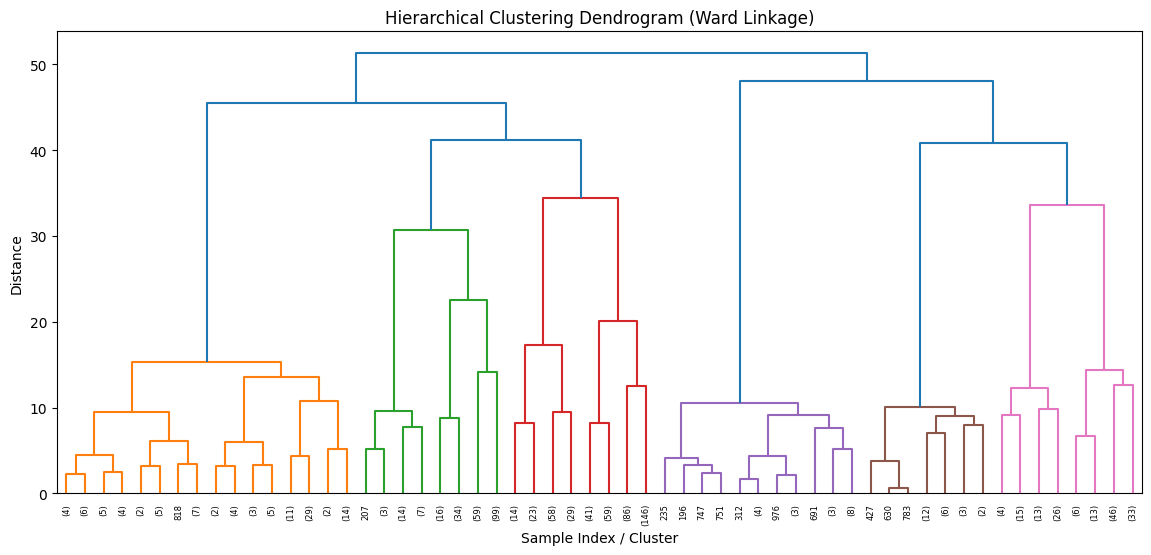

In [44]:
# Subset of the dataset because it is large
np.random.seed(42)
sample_size = 1000
idx = np.random.choice(
    x_scaled.shape[0],
    size = sample_size,
    replace = False
)
x_sampled = x_scaled[idx]

# Linkage matrix for the dendrogram
linkage_mat = linkage(x_sampled, method = "ward")

# Plot dendrogram
plt.figure(figsize = (14, 6))
dendrogram(linkage_mat, truncate_mode = "level", p = 5)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Sample Index / Cluster")
plt.ylabel("Distance")
plt.show()

**Dendrogram Interpretation:**<br/>
The dendrogram suggests a moderate cluster structure, with the largest merges occuring at higher linkage distances.<br/>
A reasonable range to test could be 3-5 clusters, since this appears to capture the main branches before large cluster merges occur.

### C2. Agglomerative Clustering

In [51]:
def run_agglomerative_clustering(
    linkage, n_clusters,
    sample_size = 2000,
    random_state = 42
):
    model = AgglomerativeClustering(
        n_clusters = n_clusters,
        linkage = linkage
    )

    labels = model.fit_predict(x_sampled)

    score = silhouette_score(
        x_sampled, labels,
        sample_size = sample_size,
        random_state = random_state
    )

    return {
        "linkage": linkage,
        "n_clusters": n_clusters,
        "silhouette_score": score
    }

In [56]:
linkage_methods = [ "ward", "complete", "average" ]
cluster_counts = [ 3, 4, 5 ]

results = []
for linkage in linkage_methods:
    for n_clusters in cluster_counts:
        result = run_agglomerative_clustering(linkage, n_clusters)
        results.append(result)

report_agglomerative_clustering = pd.DataFrame(results)
display(report)

,linkage,n_clusters,silhouette_score
0,ward,3,0.304853
1,ward,4,0.308913
2,ward,5,0.245660
3,complete,3,0.400965
4,complete,4,0.419868
5,complete,5,0.377165
6,average,3,0.483526
7,average,4,0.425828
8,average,5,0.421946


**Best Configuration:**
- Linkage method: `average`
- Nr of clusters: `3`
- Silhouette score: `0.483526`

**Interpretation:**<br/>
Different linkage methods produced clearly different results, with `average` linkage achieving the best cluster quality, while `ward` produced the weakest results.<br/>
These differences are caused by each linkage method measuring the distance between clusters differently, so some methods fit the underlying shape of the data better than others.

## D. Final Report

In [59]:
report_dbscan["method"] = "DBSCAN"
report_agglomerative_clustering["method"] = "Agglomerative"

# Pad missing columns to match tables
report_dbscan["linkage"] = np.nan
report_agglomerative_clustering["eps"] = np.nan
report_agglomerative_clustering["min_samples"] = np.nan
report_agglomerative_clustering["n_noise"] = np.nan

# Consistent column order
report_dbscan = report_dbscan[[ 
    "method", "eps", "min_samples", "n_noise",
    "n_clusters", "linkage", "silhouette_score"
]]
report_agglomerative_clustering[[
    "method", "eps", "min_samples", "n_noise",
    "n_clusters", "linkage", "silhouette_score"
]]

# Combine
final_report = pd.concat(
    [ report_dbscan, report_agglomerative_clustering ],
    ignore_index = True
)
display(final_report.fillna("-"))

,method,eps,min_samples,n_noise,n_clusters,linkage,silhouette_score
0,DBSCAN,0.3,5.0,10710.0,309,-,0.150784
1,DBSCAN,0.5,5.0,3220.0,138,-,0.290597
2,DBSCAN,1.0,5.0,553.0,64,-,0.316846
3,Agglomerative,-,-,-,3,ward,0.304853
4,Agglomerative,-,-,-,4,ward,0.308913
5,Agglomerative,-,-,-,5,ward,0.245660
6,Agglomerative,-,-,-,3,complete,0.400965
7,Agglomerative,-,-,-,4,complete,0.419868
8,Agglomerative,-,-,-,5,complete,0.377165
9,Agglomerative,-,-,-,3,average,0.483526


**Final Answer:**<br/>
I would recommend Agglomerative Clustering for this dataset, because its best configuration (average linkage, 3  clusters) produced a substantially higher silhouette score than any DBSCAN configuration.<br/>
This suggests that the hierarchical method found more meaningful and better-separated clusters. DBSCAN was less interpretable here because it created many clusters and labeled a large number of points as noise.<br/>
Overall, agglomerative clustering gave the clearest and most practical clustering structure.